In [22]:
#Referencia https://github.com/rougier/matplotlib-tutorial

## MATPLOTLIB

In [2]:
#prerequisito: pip install matplotlib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
%matplotlib inline

In [6]:
# Cargar datos
df = pd.read_csv('gapminder.csv')
df

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,1987,9216418.0,Africa,62.351,706.157306
1700,Zimbabwe,1992,10704340.0,Africa,60.377,693.420786
1701,Zimbabwe,1997,11404948.0,Africa,46.809,792.449960
1702,Zimbabwe,2002,11926563.0,Africa,39.989,672.038623


### GRAFICO DE LINEA

"¿Cómo ha evolucionado la esperanza de vida en México a lo largo de los años registrados en el estudio? ¿Es un crecimiento lineal o ha tenido estancamientos?"

In [7]:
# Filtrar por país (México)
mexico = df[df['country'] == 'Mexico']

# Extraer las variables para los ejes
años = mexico['year']
esperanza = mexico['lifeExp']

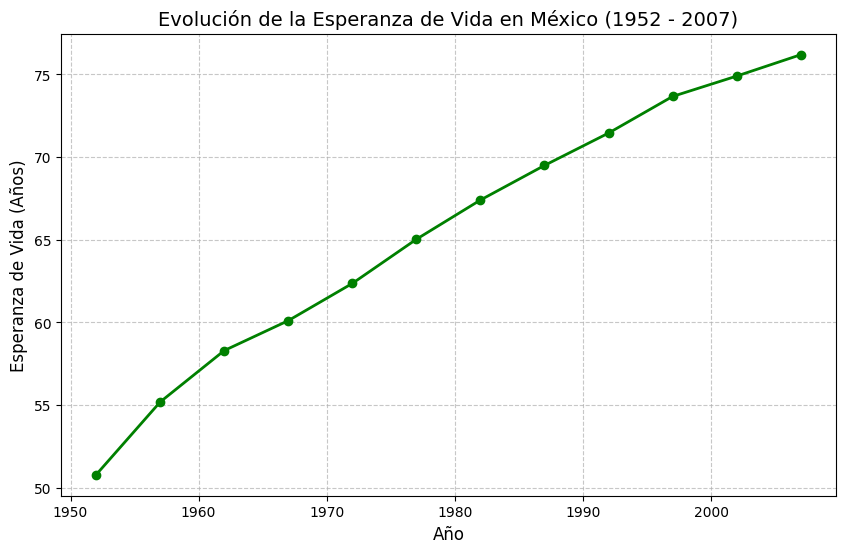

In [8]:
# Crear la figura y los ejes
plt.figure(figsize=(10, 6))

# Dibujar la línea
plt.plot(años, esperanza, color='green', marker='o', linestyle='-', linewidth=2)

# Añadir etiquetas y título
plt.title('Evolución de la Esperanza de Vida en México (1952 - 2007)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Esperanza de Vida (Años)', fontsize=12)

# Añadir una cuadrícula para facilitar la lectura
plt.grid(True, linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()

"Queremos comparar el progreso de la salud pública en cuatro países con contextos históricos muy distintos: Vietnam, Honduras, Spain y Egypt. ¿Cómo ha evolucionado su esperanza de vida desde los años 50? ¿Podemos identificar eventos históricos o tendencias compartidas al verlos todos juntos?"

In [9]:
df = pd.read_csv('gapminder.csv')

# Filtramos cada país por separado
china = df[df['country'] == 'Vietnam']
india = df[df['country'] == 'India']
spain = df[df['country'] == 'Spain']
egypt = df[df['country'] == 'Egypt']

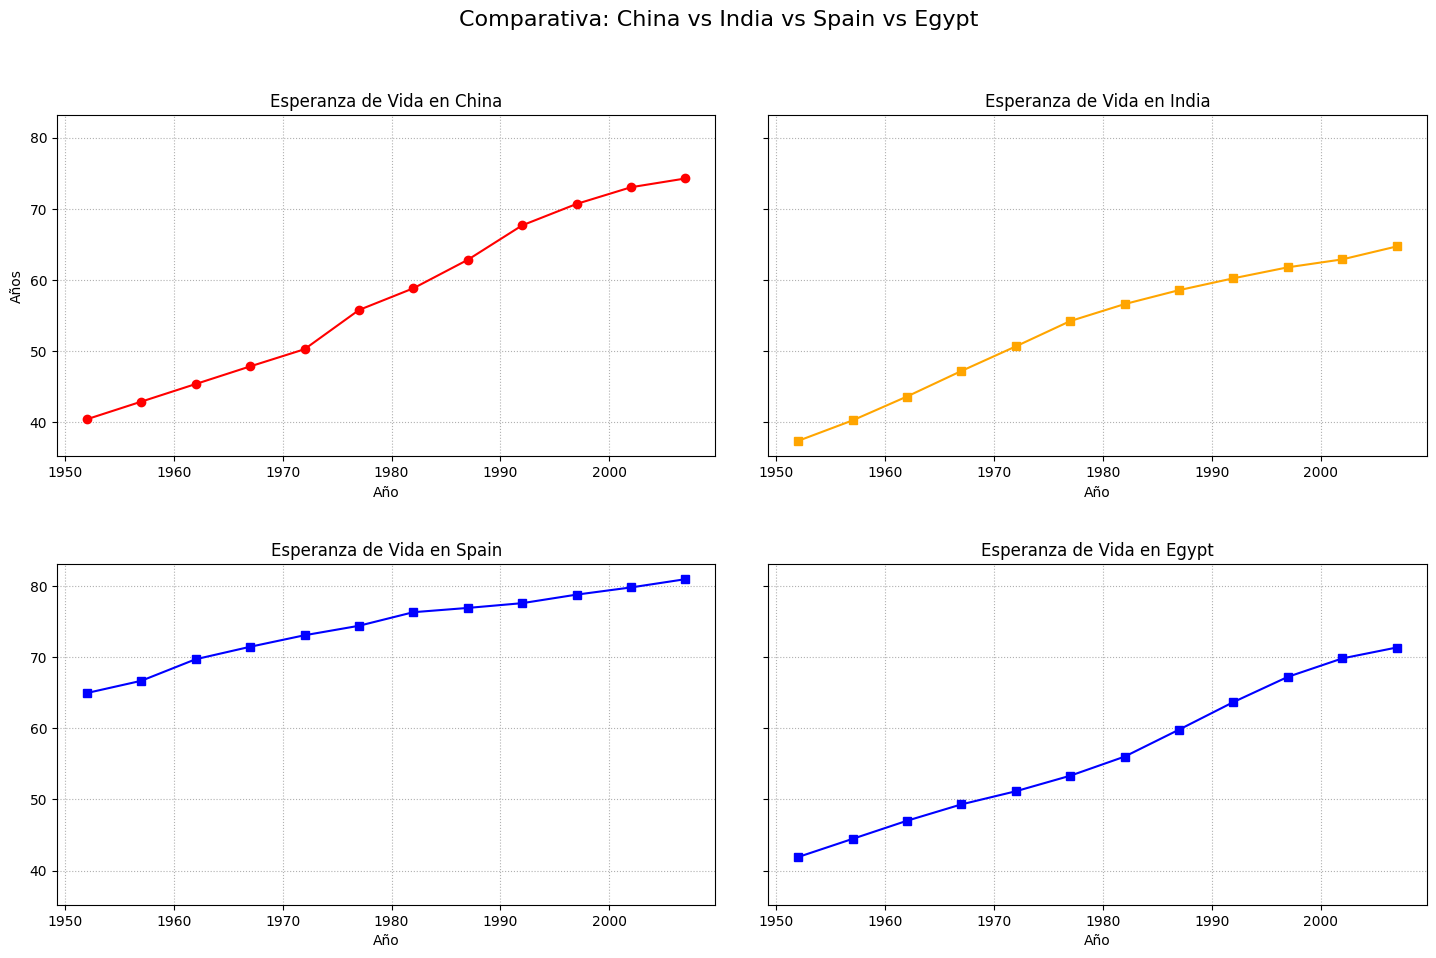

In [10]:
# Creamos la figura con 1 fila y 2 columnas
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10), sharey=True)

# --- Gráfico 1: China ---
ax1.plot(china['year'], china['lifeExp'], color='red', marker='o', label='Vietnam')
ax1.set_title('Esperanza de Vida en China')
ax1.set_xlabel('Año')
ax1.set_ylabel('Años')
ax1.grid(True, linestyle=':')

# --- Gráfico 2: India ---
ax2.plot(india['year'], india['lifeExp'], color='orange', marker='s', label='India')
ax2.set_title('Esperanza de Vida en India')
ax2.set_xlabel('Año')
ax2.grid(True, linestyle=':')

# --- Gráfico 3: Spain ---
ax3.plot(spain['year'], spain['lifeExp'], color='blue', marker='s', label='Spain')
ax3.set_title('Esperanza de Vida en Spain')
ax3.set_xlabel('Año')
ax3.grid(True, linestyle=':')

# --- Gráfico 3: Spain ---
ax4.plot(egypt['year'], egypt['lifeExp'], color='blue', marker='s', label='Egypt')
ax4.set_title('Esperanza de Vida en Egypt')
ax4.set_xlabel('Año')
ax4.grid(True, linestyle=':')

# Título global
fig.suptitle('Comparativa: China vs India vs Spain vs Egypt', fontsize=16)

plt.tight_layout(pad=3.0)

plt.show()

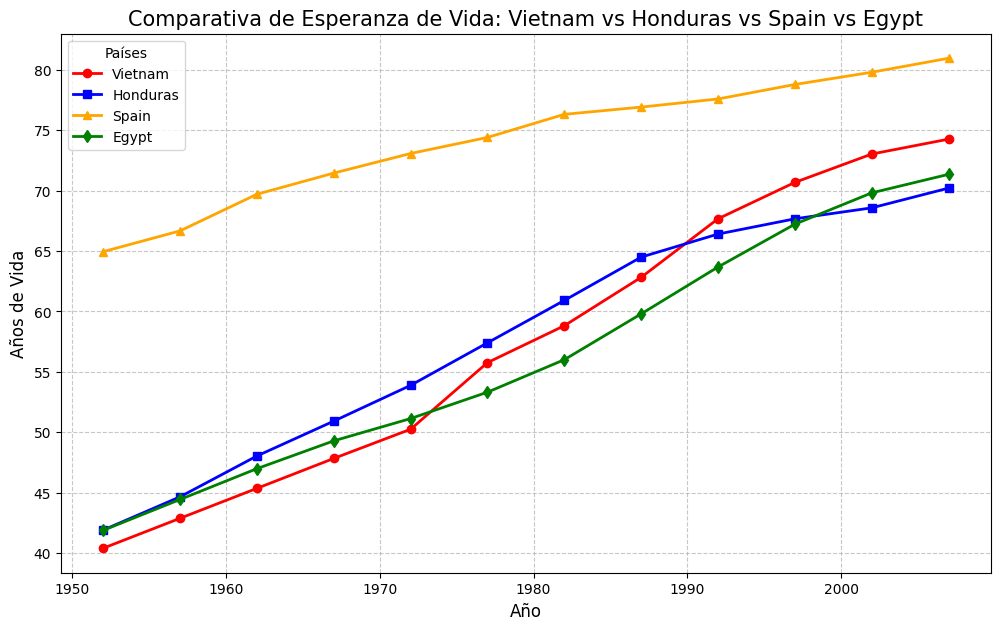

In [11]:
# 1. Preparación de datos
df = pd.read_csv('gapminder.csv')
v = df[df['country'] == 'Vietnam']
h = df[df['country'] == 'Honduras']
s = df[df['country'] == 'Spain']
e = df[df['country'] == 'Egypt']

# 2. Crear la figura y un único eje (ax)
fig, ax = plt.subplots(figsize=(12, 7))

# 3. Graficar cada uno manualmente en el mismo 'ax'
ax.plot(v['year'], v['lifeExp'], color='red', marker='o', label='Vietnam', linewidth=2)
ax.plot(h['year'], h['lifeExp'], color='blue', marker='s', label='Honduras', linewidth=2)
ax.plot(s['year'], s['lifeExp'], color='orange', marker='^', label='Spain', linewidth=2)
ax.plot(e['year'], e['lifeExp'], color='green', marker='d', label='Egypt', linewidth=2)

# 4. Personalización del gráfico
ax.set_title('Comparativa de Esperanza de Vida: Vietnam vs Honduras vs Spain vs Egypt', fontsize=15)
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Años de Vida', fontsize=12)

# Activar la leyenda para saber qué color es cada país
ax.legend(title="Países", loc='upper left')

# Añadir rejilla para facilitar la lectura de los años
ax.grid(True, linestyle='--', alpha=0.7)

plt.show()

### GRAFICO DE BARRAS

"Si tomamos el año 2007, ¿cuál es el PIB per cápita promedio por continente? ¿Es África realmente el continente con menos ingresos promedio, o hay otros que se le acercan? Vamos a visualizar la riqueza global agrupada por grandes regiones."

In [12]:
# 1. Filtramos por el último año
df_2007 = df[df['year'] == 2007]

# 2. Agrupamos por continente y calculamos el promedio del PIB
# Esto reduce los cientos de países a solo 5 filas (continentes)
continente_pib = df_2007.groupby('continent')['gdpPercap'].mean().sort_values()

# Extraemos los datos para Matplotlib
nombres_cont = continente_pib.index
valores_pib = continente_pib.values

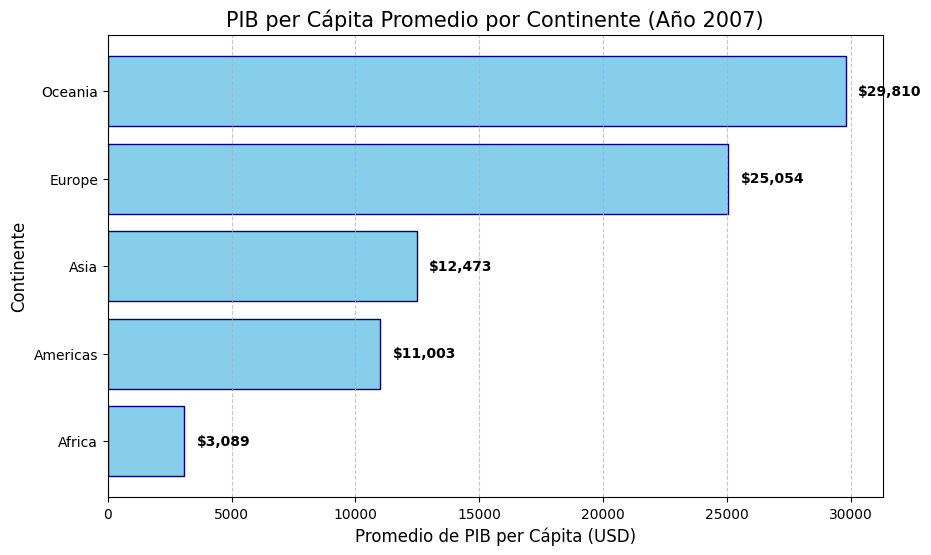

In [13]:
# Crear la figura
plt.figure(figsize=(10, 6))

# Dibujar barras horizontales
plt.barh(nombres_cont, valores_pib, color='skyblue', edgecolor='navy')

# Añadir títulos y etiquetas
plt.title('PIB per Cápita Promedio por Continente (Año 2007)', fontsize=15)
plt.xlabel('Promedio de PIB per Cápita (USD)', fontsize=12)
plt.ylabel('Continente', fontsize=12)

# Añadir rejilla solo en el eje X para medir mejor
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Mostrar el valor exacto al final de cada barra para mayor claridad
for i, v in enumerate(valores_pib):
    plt.text(v + 500, i, f'${v:,.0f}', va='center', fontweight='bold')

plt.show()

### GRAFICO DE BARRAS APILADAS

"Si comparamos a México y España, ¿cuál ha sido el país que más ha crecido en esperanza de vida desde los años 50? Vamos a poner una barra al lado de la otra para cada año y ver quién gana la carrera por la longevidad."

In [14]:
# Filtramos solo dos países y dos años clave (el inicio y el fin)
mexico = df[(df['country'] == 'Mexico') & (df['year'].isin([1952, 2007]))]
spain = df[(df['country'] == 'Spain') & (df['year'].isin([1952, 2007]))]

# Extraemos los valores de esperanza de vida
valores_mex = mexico['lifeExp'].values # [valor_1952, valor_2007]
valores_spa = spain['lifeExp'].values  # [valor_1952, valor_2007]
años_etiquetas = ['1952', '2007']

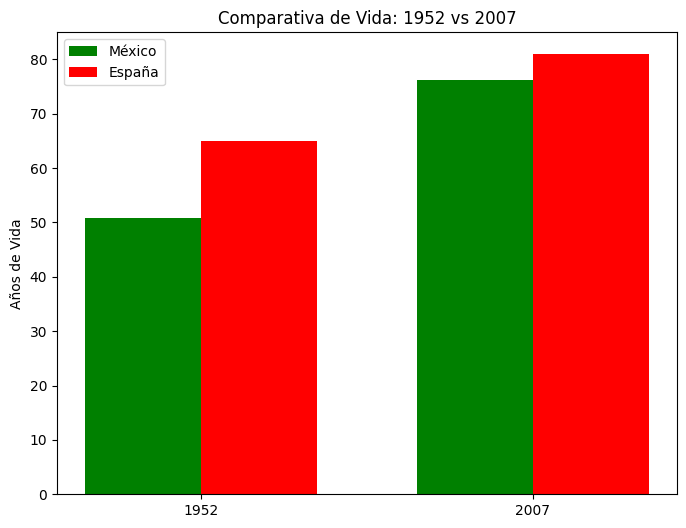

In [18]:
x = np.arange(len(años_etiquetas)) # La posición de las etiquetas (0 y 1)
ancho = 0.35 # El ancho de cada barrita

plt.figure(figsize=(8, 6))

# Dibujamos las barras de México movidas un poquito a la izquierda
plt.bar(x - ancho/2, valores_mex, ancho, label='México', color='green')

# Dibujamos las barras de España movidas un poquito a la derecha
plt.bar(x + ancho/2, valores_spa, ancho, label='España', color='red')

# Ponemos los nombres de los años en el centro
plt.xticks(x, años_etiquetas)

plt.ylabel('Años de Vida')
plt.title('Comparativa de Vida: 1952 vs 2007')
plt.legend()

plt.show()

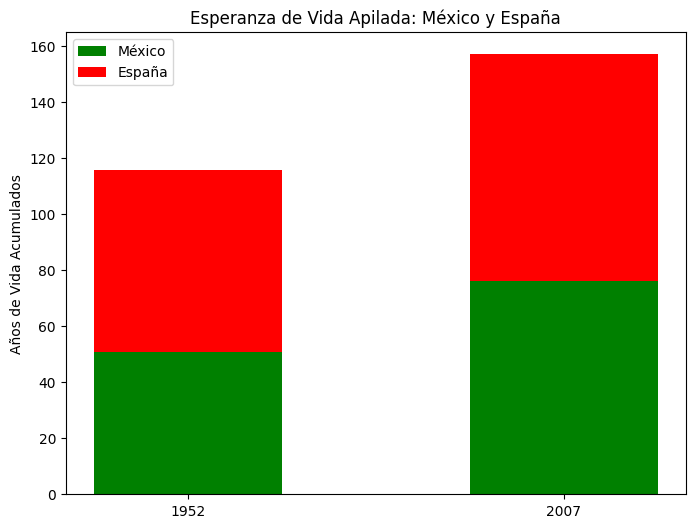

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Filtramos solo dos países y dos años clave (el inicio y el fin)
mexico = df[(df['country'] == 'Mexico') & (df['year'].isin([1952, 2007]))]
spain = df[(df['country'] == 'Spain') & (df['year'].isin([1952, 2007]))]

# Extraemos los valores de esperanza de vida
valores_mex = mexico['lifeExp'].values # [valor_1952, valor_2007]
valores_spa = spain['lifeExp'].values  # [valor_1952, valor_2007]
años_etiquetas = ['1952', '2007']

x = np.arange(len(años_etiquetas)) 
ancho = 0.5 # Podemos hacerlas un poco más anchas ya que no compiten por espacio lateral

plt.figure(figsize=(8, 6))

# 1. Dibujamos la base (México)
plt.bar(x, valores_mex, ancho, label='México', color='green')

# 2. Dibujamos la cima (España) usando 'bottom'
# Esto coloca los valores de España justo encima de los de México
plt.bar(x, valores_spa, ancho, bottom=valores_mex, label='España', color='red')

# Ajustes de estética
plt.xticks(x, años_etiquetas)
plt.ylabel('Años de Vida Acumulados')
plt.title('Esperanza de Vida Apilada: México y España')
plt.legend()

plt.show()

### GRAFICO DE TORTA

"En el año 2007, ¿cómo se distribuía la población mundial entre los continentes? ¿Es cierto que Asia concentra a más de la mitad de la humanidad o el resto de los continentes sumados le ganan?"

In [21]:
# 1. Filtramos el año 2007
df_2007 = df[df['year'] == 2007]

# 2. Agrupamos por continente y sumamos su población
pop_por_continente = df_2007.groupby('continent')['pop'].sum()
pop_por_continente

continent
Africa      9.295397e+08
Americas    8.988712e+08
Asia        3.811954e+09
Europe      5.860985e+08
Oceania     2.454995e+07
Name: pop, dtype: float64

In [22]:
# Extraemos etiquetas y valores
etiquetas = pop_por_continente.index
valores = pop_por_continente.values

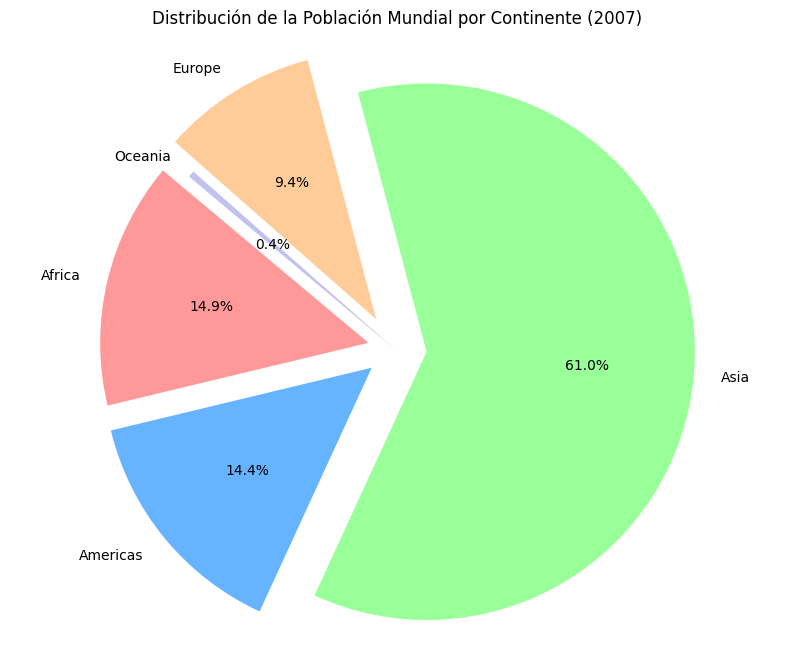

In [28]:
# Crear la figura
plt.figure(figsize=(10, 8))

# Dibujar el gráfico de torta
# autopct='%1.1f%%' sirve para mostrar el porcentaje automáticamente
plt.pie(valores, 
        labels=etiquetas, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'],
        explode=(0.1, 0.11, 0.12, 0.13, 0)) # "Saca" un pedacito (África) para resaltar

plt.title('Distribución de la Población Mundial por Continente (2007)')

# Asegura que el gráfico sea un círculo perfecto
plt.axis('equal') 

plt.show()

### GRAFICO DE DISPERCION

"¿Existe realmente una relación entre la riqueza de un país y la salud de sus habitantes? Si graficamos el PIB per cápita frente a la Esperanza de Vida de todos los países en el año 2007, ¿veremos una línea ascendente o los puntos estarán dispersos sin orden alguno?"

In [30]:
# Filtramos solo el año 2007 para todos los países disponibles
data_2007 = df[df['year'] == 2007]

# Extraemos las variables
pib = data_2007['gdpPercap']
esperanza = data_2007['lifeExp']
poblacion = data_2007['pop'] / 1000000

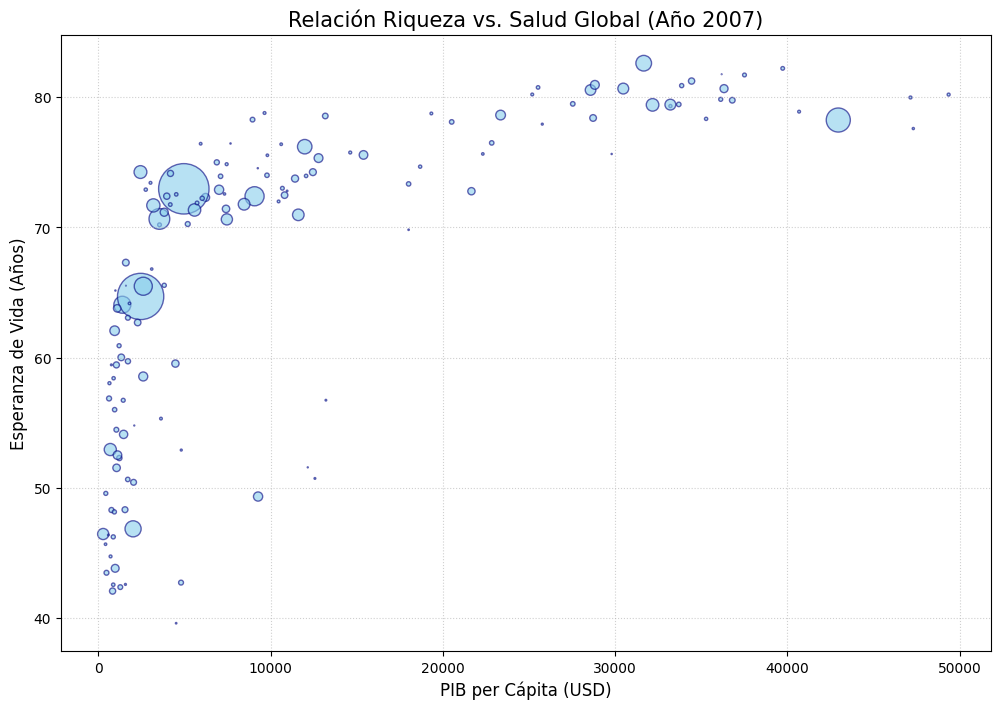

In [31]:
plt.figure(figsize=(12, 8))

# Dibujar los puntos
# s es el tamaño (size) basado en la población
# alpha es la transparencia (útil cuando los puntos se enciman)
plt.scatter(pib, esperanza, s=poblacion, c='skyblue', edgecolors='navy', alpha=0.6)

# Personalización
plt.title('Relación Riqueza vs. Salud Global (Año 2007)', fontsize=15)
plt.xlabel('PIB per Cápita (USD)', fontsize=12)
plt.ylabel('Esperanza de Vida (Años)', fontsize=12)

# Añadir rejilla para ver mejor los cuadrantes
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

### GRAFICO DE HISTOGRAMA

"Si analizamos todos los países del mundo en el año 2007, ¿cuál es la esperanza de vida más común? ¿Hay más países en la zona de 'longevidad alta' (más de 70 años) o todavía hay una gran cantidad de países atrapados en rangos bajos?"

In [32]:
# Filtramos los datos del último año para todos los países
data_2007 = df[df['year'] == 2007]

# Extraemos la columna que queremos analizar
esperanza_vida = data_2007['lifeExp']
esperanza_vida

11      43.828
23      76.423
35      72.301
47      42.731
59      75.320
         ...  
1655    74.249
1667    73.422
1679    62.698
1691    42.384
1703    43.487
Name: lifeExp, Length: 142, dtype: float64

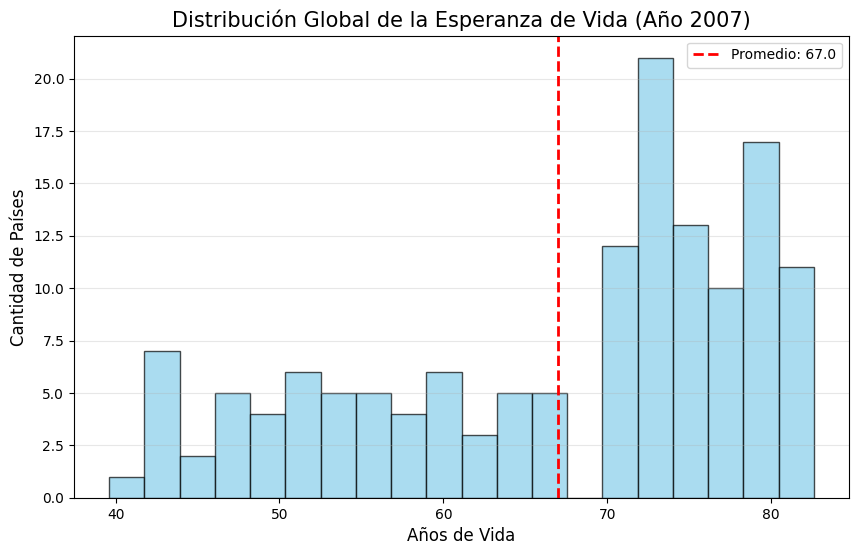

In [33]:
plt.figure(figsize=(10, 6))

# Dibujar el histograma
# bins=20 crea 20 barras de rango
# color y edgecolor ayudan a que se vea limpio
plt.hist(esperanza_vida, bins=20, color='skyblue', edgecolor='black', alpha=0.7)

# Personalización
plt.title('Distribución Global de la Esperanza de Vida (Año 2007)', fontsize=15)
plt.xlabel('Años de Vida', fontsize=12)
plt.ylabel('Cantidad de Países', fontsize=12)

# Añadir una línea para marcar el promedio (opcional pero muy educativo)
promedio = esperanza_vida.mean()
plt.axvline(promedio, color='red', linestyle='dashed', linewidth=2, label=f'Promedio: {promedio:.1f}')

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()